#  Group Term paper 1 
**Candidate number 67 and 129**
***

<h3 style="color: steelblue; font-size: 2em; font-weight: bold;">Peer review comments</h3>

**1. Does the notebook execute without errors?**

The notebook runs without errors and all parts appear to execute correctly.

**2. Is the code well-structured and easy to read?**

The code is generally well structured and divided into logical parts corresponding to each part of the assignment. Functions and classes are used appropriately, which improves readability. However, some parts could benefit from clearer markdown explanations and more comments, especially in Part 3 (transition dynamics), Part 4 (wealth tax), and Part 6 (uncertainty), where the economic intuition and steps in the code could be explained more clearly.

**3. Does the code use functions to avoid code duplication?**

Yes, the code uses functions and classes to avoid duplication, such as functions for computing prices, Euler equation errors, steady state, and simulations. This makes the code modular and easier to maintain and reuse.

**4. Does the code use vectorization instead of loops for efficiency, where applicable?**

NumPy and vectorized operations are used where appropriate. Loops are mainly used in the transition simulation over time, which is reasonable for this type of dynamic model. Overall, the code seems efficient.

**5. Are the solutions correct (as compared to the suggested solutions posted on Canvas)?**

The results appear to be consistent with the suggested solution, particularly the steady state values, transition dynamics, and the effects of the wealth tax. The qualitative results, such as lower capital with a wealth tax and welfare effects across households, are in line with the solution.

**6. Have you come up with a better approach in your own solution that you can share as feedback?**

In our own solution, we used pandas DataFrames to present results and model parameters in tables instead of printing values line by line, which made the results more structured and easier to read. But pandas has not been covered in detail in the course, so this is only an optional suggestion if you want to take a look into.

## 
**Importing**
***

In [24]:
import numpy as np
from scipy import optimize
import matplotlib.pyplot as plt
from dataclasses import dataclass

## Part 1 - Euler equation errors
***

In [25]:
@dataclass
class Parameters:
        beta = 0.99**30
        gamma = 2.1
        tau = 0.3
        phi = 0.5
        alpha = 0.36
        delta = 1 - 0.94**30
        z = 1.0
        Nw = 0.8
        Nk = 0.2
        tau_a = 0.0
        tau_a_iid = 0.05
        pi_a = 0.5

par = Parameters()

In [26]:
def euler_err(K_next, K, par):
    """
    Compute the capitalists' Euler equation error for a given capital
    stock today and tomorrow.
    """
    # Labor supply
    L = 0.5 * par.Nw

    # Interest rates from firm FOC, at time t and t+1
    r = par.alpha * par.z * K**(par.alpha - 1) * L**(1 - par.alpha) - par.delta
    r_next = par.alpha * par.z * K_next**(par.alpha - 1) * L**(1 - par.alpha) - par.delta

    # Young capitalist's saving
    a = (2 * K_next) / par.Nk

    # Lump-sum tax on capitalists
    Ta = par.tau_a * (1 + r) * K
    Ta_next = par.tau_a * (1 + r_next) * K_next

    # Inheritance to young capitalists
    b = par.phi * (1 - par.tau_a) * (1 + r) * (2 * K /par.Nk)

    # Consumption of young and old capitalists
    cK_y = b + Ta - a
    cK_o = (1 - par.phi) * (1 - par.tau_a) * (1 + r_next) * a + Ta_next

    # Euler equation error
    LHS = cK_y**(-par.gamma)
    RHS = par.beta * (1 + r_next) * (1 - par.tau_a) * (1 - par.phi) * cK_o**(-par.gamma)

    return LHS - RHS

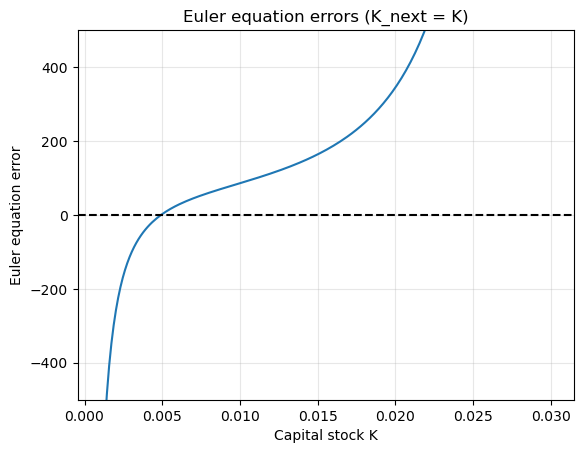

In [27]:
K_grid = np.linspace(0.001, 0.03, 200)
errors = [euler_err(K, K, par) for K in K_grid]

plt.figure()
plt.plot(K_grid, errors)
plt.grid(alpha = 0.3)
plt.axhline(0, color='black', linestyle='--')
plt.xlabel('Capital stock K')
plt.ylabel('Euler equation error')
plt.title('Euler equation errors (K_next = K)')
plt.ylim(-500, 500)
plt.show()

The plot shows that the Euler equation error crosses zero around $K \approx 0.005$, confirming that the function has a root. At this point, the Euler equation holds, indiacting that capital is at its steady-state level. We used 200 points in the interval \([0.001, 0.03]\) to show this.

<h3 style="color: steelblue; font-size: 2em; font-weight: bold;">Peer review comments - Part 1</h3>

- The Euler equation error function appears to be implemented correctly and is consistent with the model setup.
- Plotting the Euler equation error to identify the steady state capital stock is a good approach and consistent with the suggested solution.
- However, the paper could include a short explanation of the economic intuition behind the Euler equation. For example, explain that the Euler equation represents the trade-off between consuming today and saving to consume tomorrow, and that the equilibrium capital stock is found where households are indifferent between these choices.


## Part 2 - Steady state
***

In [28]:
@dataclass
class SteadyState:
    """Stores all steady-state quantities and prices"""
    pass

In [29]:
def compute_steady_state(par, euler_func = euler_err):
    
    K_ss = optimize.brentq(lambda K: euler_func(K, K, par), 0.001, 0.02)

    ss = SteadyState()
    ss.K = K_ss

    # Labor supply
    ss.L = 0.5 * par.Nw

    # Prices for capital and labor
    ss.r = par.alpha * par.z * ss.K**(par.alpha - 1) * ss.L**(1 - par.alpha) - par.delta
    ss.w = (1 - par.alpha) * par.z * ss.K**par.alpha * ss.L**(-par.alpha)

    # Lump sum tax on capital
    ss.Ta = par.tau_a * (1 + ss.r) * ss.K

    # Output
    ss.Y = par.z * ss.K**par.alpha * ss.L**(1 - par.alpha)

    # Capitalist variables
    ss.a = (2 * ss.K) / par.Nk
    ss.b = par.phi * (1 - par.tau_a) * (1 + ss.r) * ss.a
    ss.cK_y = ss.b + ss.Ta - ss.a
    ss.cK_o = (1 - par.phi) * (1 - par.tau_a) * (1 + ss.r) * ss.a + ss.Ta
    ss.s = ss.a / (ss.b + ss.Ta)

    # Worker variables
    ss.p = par.tau * ss.w
    ss.cW_y = (1 - par.tau) * ss.w + ss.Ta
    ss.cW_o = ss.p + ss.Ta

    # Goods market check - supply should equal demand
    supply = ss.Y + (1 - par.delta) * ss.K
    demand = (0.5 * par.Nw * (ss.cW_y + ss.cW_o) + 0.5 * par.Nk * (ss.cK_y + ss.cK_o +ss.a))
    ss.goods_error = supply - demand

    # Annualized interest rate over 30 years
    ss.r_annual = (1 + ss.r)**(1/30) - 1

    return ss

In [30]:
ss = compute_steady_state(par)

print("Steady-state equilibrium:")
print(f"  Output Y                 = {ss.Y:.6f}")
print(f"  Capital K                = {ss.K:.6f}")
print(f"  Wage w                   = {ss.w:.6f}")
print(f"  Interest r               = {ss.r:.6f}")
print(f"  Bequest b                = {ss.b:.6f}")
print(f"  Savings a                = {ss.a:.6f}")
print(f"  c of worker(young)       = {ss.cW_y:.6f}")
print(f"  c of worker(old)         = {ss.cW_o:.6f}")
print(f"  c of capital(young)      = {ss.cK_y:.6f}")
print(f"  c of capital(old)        = {ss.cK_o:.6f}")
print(f"  Goods market error       = {ss.goods_error:.6f}")
print(f"  Annualized interest rate = {ss.r_annual*100:.6f}%")

Steady-state equilibrium:
  Output Y                 = 0.082129
  Capital K                = 0.004922
  Wage w                   = 0.131407
  Interest r               = 5.162944
  Bequest b                = 0.151678
  Savings a                = 0.049223
  c of worker(young)       = 0.091985
  c of worker(old)         = 0.039422
  c of capital(young)      = 0.102456
  c of capital(old)        = 0.151678
  Goods market error       = 0.000000
  Annualized interest rate = 6.249348%


The model has a 30-year interest rate of 516%. To check if this rate is realistic, we annualize the rate over 30 years. The annualized net interest rate of 6.25% is a reasonable value. The goods market error is equal to 0, indicating that supply equals demand.

<h3 style="color: steelblue; font-size: 2em; font-weight: bold;">Peer review comments - Part 2</h3>

- The steady state is computed using a root finder and the Euler equation, which is the correct method (the solution did to).
- The steady state results appear to be consistent with the suggested solution.
- However, the economic interpretation of the steady state results could be expanded. For example, the authors could explain how a higher capital stock affects wages and interest rates through the production function.
- The paper could also include a short discussion of whether the implied interest rate is economically reasonable.


## Part 3 - Transition dynamics
***

In [31]:
class Simulation:
    """Stores simulated time series of all model variables."""
    pass

In [32]:
def simulate_olg(K0, T, par, euler_func=euler_err):
    """Simulate the OLG model for T periods"""

    sim = Simulation()

    sim.K = np.zeros(T + 1)
    sim.Y = np.zeros(T)
    sim.r = np.zeros(T)
    sim.w = np.zeros(T)
    sim.a = np.zeros(T)
    sim.b = np.zeros(T)
    sim.s = np.zeros(T)
    sim.cW_y = np.zeros(T)
    sim.cW_o = np.zeros(T)
    sim.cK_y = np.zeros(T)
    sim.cK_o = np.zeros(T)

    #Tax from part 4
    sim.Ta = np.zeros(T)

    # Labor supply
    L = 0.5 * par.Nw

    # Initial capital 
    sim.K[0] = K0

    # Loop over all periods
    for t in range(T):
        K = sim.K[t]

        # Prices
        sim.r[t] = par.alpha * par.z * K**(par.alpha - 1) * L**(1 - par.alpha) - par.delta
        sim.w[t] = (1 - par.alpha) * par.z * K**par.alpha * L**(-par.alpha)
        sim.Y[t] = par.z * K**par.alpha * L**(1 - par.alpha)
        sim.Ta[t] = par.tau_a * (1 + sim.r[t]) * sim.K[t]

        # Capitalist variables
        sim.b[t] = par.phi * (1 - par.tau_a) * (1 + sim.r[t]) * (2 * K / par.Nk)

        # Find next period capital using root-finder
        if t < T - 1:
            K_upper = (sim.b[t] + sim.Ta[t]) * par.Nk / 2 * 0.99 #Max amount that can be saved, avoiding negative consumption
            K_next = optimize.brentq(lambda Kn: euler_func(Kn, K, par), 0.0001, K_upper)
            sim.K[t + 1] = K_next
        else:
            sim.K[t + 1] = sim.K[t]

        # Capitalist savings and consumption
        sim.a[t] = 2 * sim.K[t + 1] / par.Nk
        sim.cK_y[t] = sim.b[t] + sim.Ta[t] - sim.a[t]
        sim.cK_o[t] = (1 - par.phi) * (1 - par.tau_a) * (1 + sim.r[t]) * (2 * K / par.Nk) + sim.Ta[t]
        sim.s[t] = sim.a[t] / (sim.b[t] + sim.Ta[t])

        # Worker consumption
        sim.cW_y[t] = (1 - par.tau) * sim.w[t] + sim.Ta[t]
        sim.cW_o[t] = par.tau * sim.w[t] + sim.Ta[t]

        # Goods market clearing
        demand = (0.5 * par.Nw * (sim.cW_y[t] + sim.cW_o[t]) + 0.5 * par.Nk * (sim.cK_y[t] + sim.cK_o[t] + sim.a[t]))
        supply = sim.Y[t] + (1 - par.delta) * sim.K[t]

        assert abs(demand - supply) < 1e-8 # Returns error if goods market does not clear

    return sim

In [33]:
# Simulate 20 periods, starting with 0.5 times the steady-state capital
sim = simulate_olg(ss.K / 2, 20, par)

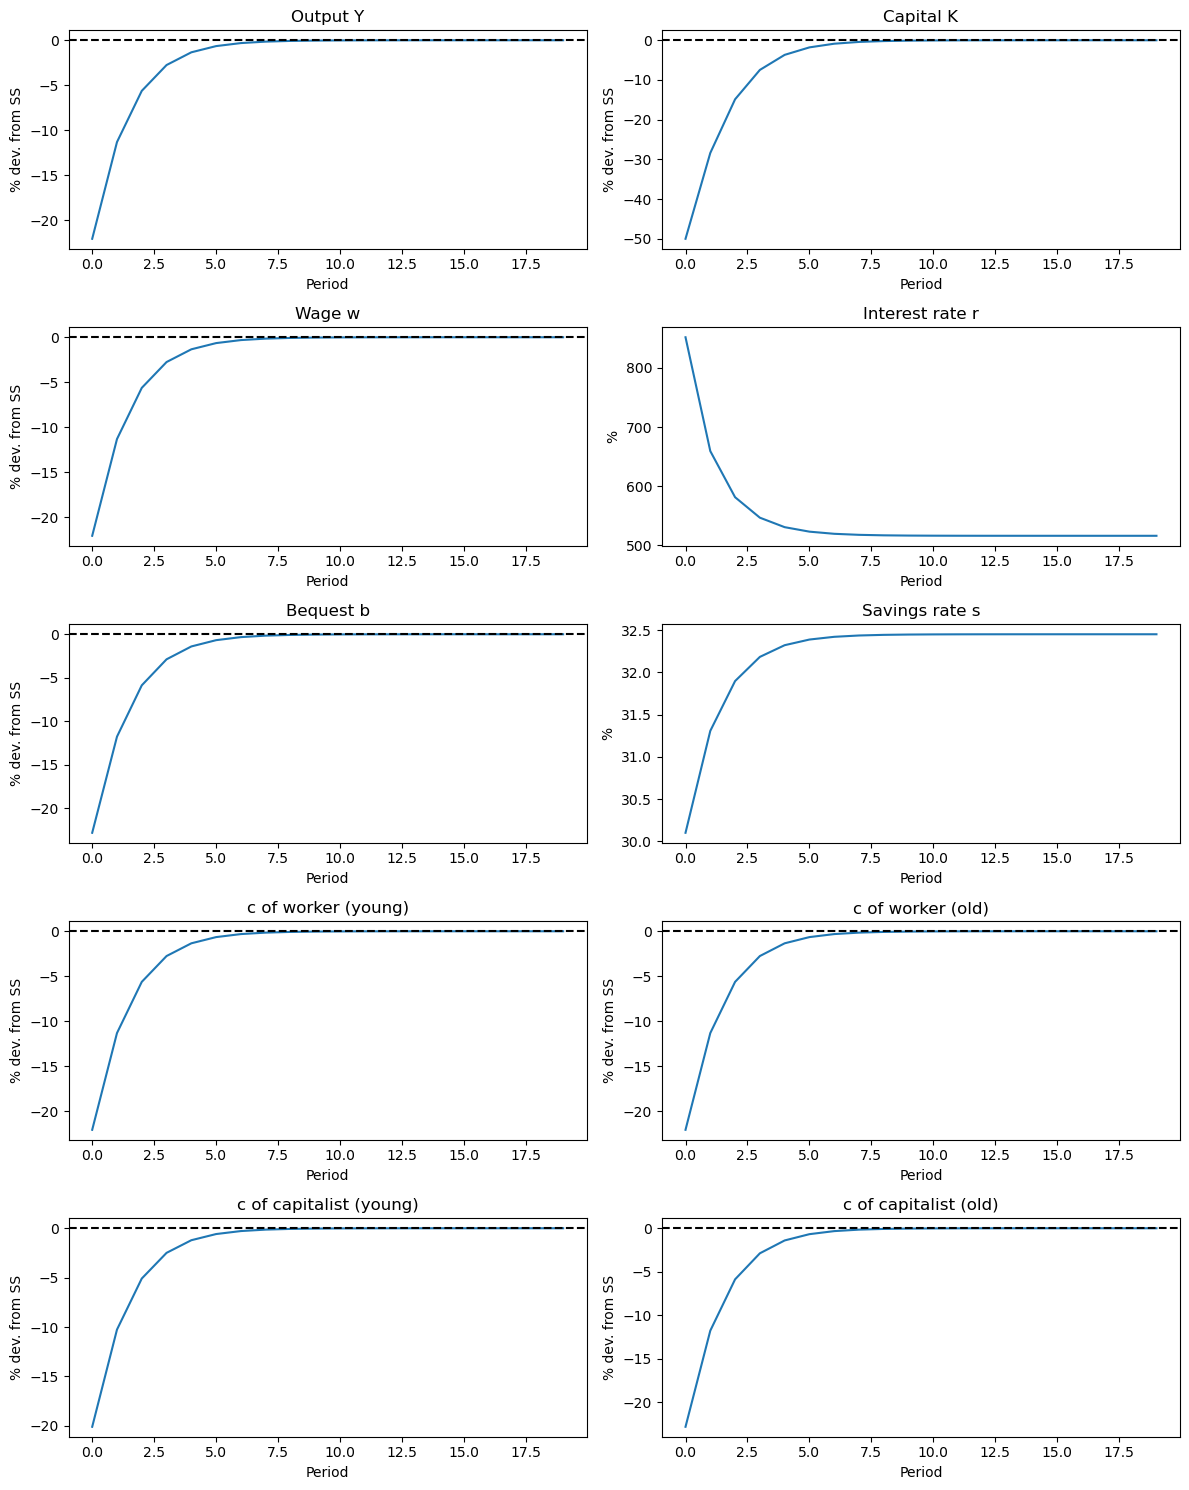

In [34]:
fig, axes = plt.subplots(5, 2, figsize=(12, 15))

# Variables as percent deviation from steady state
pct_vars = [
    (sim.Y, ss.Y, 'Output Y'),
    (sim.K[:-1], ss.K, 'Capital K'), # As sim.K has T+1 elements, we index it to T-1
    (sim.w, ss.w, 'Wage w'),
    (sim.r, None, 'Interest rate r'),
    (sim.b, ss.b, 'Bequest b'),
    (sim.s, None, 'Savings rate s'),
    (sim.cW_y, ss.cW_y, 'c of worker (young)'),
    (sim.cW_o, ss.cW_o, 'c of worker (old)'),
    (sim.cK_y, ss.cK_y, 'c of capitalist (young)'),
    (sim.cK_o, ss.cK_o, 'c of capitalist (old)'),
]

for i, (series, ss_val, label) in enumerate(pct_vars):
    ax = axes[i // 2, i % 2]

    #If no steady state
    if ss_val is None:
        ax.plot(100 * series)
        ax.set_ylabel('%')

    #If steady state
    else:
        ax.plot(100 * (series - ss_val) / ss_val)
        ax.axhline(0, color='black', linestyle='--')
        ax.set_ylabel('% dev. from SS')
    ax.set_title(label)
    ax.set_xlabel('Period')

plt.tight_layout()
plt.show()

Starting with $0.5K$, the economy converges to the steady state. Consumption, wages, output and bequest increase, whilst the interest rate decreases. With low levels of capital, this capital is highly productive, giving high rates of return. With increasing levels, the marginal product of capital decreases, which in turn makes all variables move back to steady-state.

<h3 style="color: steelblue; font-size: 2em; font-weight: bold;">Peer review comments - Part 3</h3>

- The transition dynamics simulation appears to be implemented correctly and the economy converges to the steady state.
- Using a root finder in each period to determine next period capital is the correct approach.
- The plots showing deviations from steady state are useful, but the economic interpretation of the results could maybe be expanded.

## Part 4 - Introduction of a wealth tax
***

In [35]:
# Save old steady state
ss_old = ss

# Set wealth tax rate
par.tau_a = 0.05

# New steady state
ss_new = compute_steady_state(par)

print("New steady state with wealth tax:")
print(f"   Output Y                = {ss_new.Y:.6f}")
print(f"   Capital K               = {ss_new.K:.6f}")
print(f"   Wage w                  = {ss_new.w:.6f}")
print(f"   Interest r              = {ss_new.r:.6f}")
print(f"   Savings rate            = {ss_new.s*100:.2f}%")
print(f"   Tax                     = {ss_new.Ta:.6f}")
print(f"   c of worker(young)      = {ss_new.cW_y:.6f}")
print(f"   c of worker(old)        = {ss_new.cW_o:.6f}")
print(f"   c of capital(young)     = {ss_new.cK_y:.6f}")
print(f"   c of capital(old)       = {ss_new.cK_o:.6f}")

print(f"\nChange in capital: {100*(ss_new.K - ss_old.K)/ss_old.K:.2f}%")
print(f"Change in savings rate: {100*(ss_new.s - ss_old.s):.2f} pp")

New steady state with wealth tax:
   Output Y                = 0.079977
   Capital K               = 0.004572
   Wage w                  = 0.127963
   Interest r              = 5.453349
   Savings rate            = 32.28%
   Tax                     = 0.001475
   c of worker(young)      = 0.091049
   c of worker(old)        = 0.039864
   c of capital(young)     = 0.095907
   c of capital(old)       = 0.141629

Change in capital: -7.11%
Change in savings rate: -0.17 pp


The wealth tax reduces the capital stock by 7.11% and the savings rate by 0.17 percentage points. This is because the tax lowers the return on savings for capitalists, so they save less. 

In [36]:
sim2 = simulate_olg(ss_old.K, 20, par)

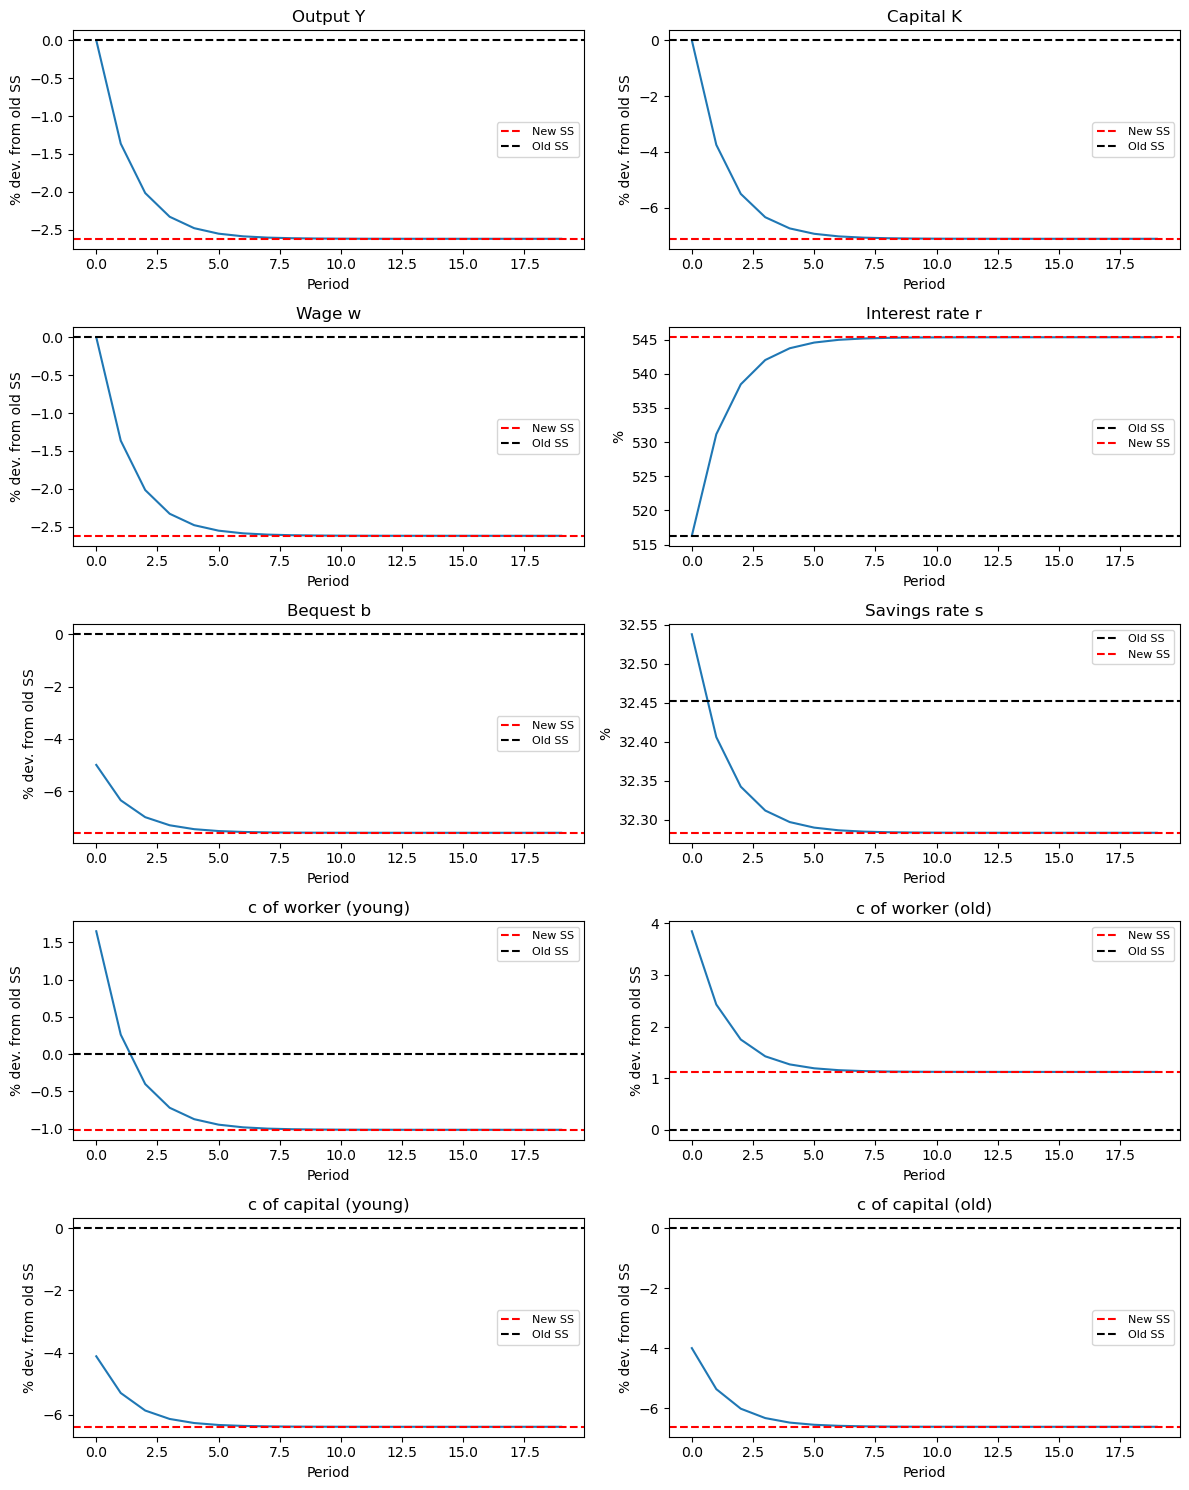

In [37]:
fig, axes = plt.subplots(5, 2, figsize=(12, 15))

pct_vars = [
    (sim2.Y, ss_old.Y, ss_new.Y, 'Output Y'),
    (sim2.K[:-1], ss_old.K, ss_new.K, 'Capital K'),
    (sim2.w, ss_old.w, ss_new.w, 'Wage w'),
    (sim2.r, ss_old.r, ss_new.r, 'Interest rate r'),
    (sim2.b, ss_old.b, ss_new.b, 'Bequest b'),
    (sim2.s, ss_old.s, ss_new.s, 'Savings rate s'),
    (sim2.cW_y, ss_old.cW_y, ss_new.cW_y, 'c of worker (young)'),
    (sim2.cW_o, ss_old.cW_o, ss_new.cW_o, 'c of worker (old)'),
    (sim2.cK_y, ss_old.cK_y, ss_new.cK_y, 'c of capital (young)'),
    (sim2.cK_o, ss_old.cK_o, ss_new.cK_o, 'c of capital (old)'),
]

for i, (series, old, new, label) in enumerate(pct_vars):
    ax = axes[i // 2, i % 2]
    if label in ['Interest rate r', 'Savings rate s']:
        ax.plot(100 * series)
        ax.axhline(100 * old, color='black', linestyle='--', label='Old SS')
        ax.axhline(100 * new, color='red', linestyle='--', label='New SS')
        ax.legend(fontsize=8)
        ax.set_ylabel('%')
    else:
        ax.plot(100 * (series - old) / old)
        ax.axhline(100 * (new - old) / old, color='red', linestyle='--', label='New SS')
        ax.axhline(0, color='black', linestyle='--', label='Old SS')
        ax.legend(fontsize=8)
        ax.set_ylabel('% dev. from old SS')
    ax.set_title(label)
    ax.set_xlabel('Period')

plt.tight_layout()
plt.show()

Young workers are slightly worse off in the new steady state as lower wages outweigh the transfer. Old workers are better off since the transfer more than compensates for the wage decline. Along the transition, workers initially benefit from transfers while capital is still high. Capitalists are worse off both along the transition and in the new steady state as the tax directly reduces their after tax returns and wealth.

<h3 style="color: steelblue; font-size: 2em; font-weight: bold;">Peer review comments - Part 4</h3>

- The wealth tax is implemented correctly and the new steady state results are consistent with the suggested solution.
- The decrease in capital and output in the new steady state is correctly identified.
- The transition dynamics after the introduction of the wealth tax appear to be implemented correctly.
- The discussion of who benefits and who loses from the wealth tax could be more detailed and include more economic intuition. For example, explain that old workers benefit from transfers financed by the wealth tax, while capitalists lose due to lower after-tax returns and smaller bequests.


## Part 5 - Social welfare and the optimal wealth tax
***

In [38]:
def crra_utility(c, gamma):
    """CRRA utility function."""
    if gamma == 1:
        return np.log(c)
    else:
        return c**(1 - gamma) / (1 - gamma)

In [39]:
def social_welfare(ss, par):
    """Compute utilitarian social welfare in steady state."""

    # Lifetime utility of young worker 
    uW_y = crra_utility(ss.cW_y, par.gamma) + par.beta * crra_utility(ss.cW_o, par.gamma)
    # One-period utility of old worker
    uW_o = crra_utility(ss.cW_o, par.gamma)
    # Lifetime utility of young capitalist 
    uK_y = crra_utility(ss.cK_y, par.gamma) + par.beta * crra_utility(ss.cK_o, par.gamma)
    # One-period utility of old capitalist
    uK_o = crra_utility(ss.cK_o, par.gamma)

    # Weighted average: 1/2 * N_type for each cohort 
    SW = 0.5 * par.Nw * (uW_y + uW_o) + 0.5 * par.Nk * (uK_y + uK_o)
    return SW

In [40]:
# Welfare without wealth tax
par.tau_a = 0.0
ss_no_tax = compute_steady_state(par)
SW_no_tax = social_welfare(ss_no_tax, par)

# Welfare with wealth tax
par.tau_a = 0.05
ss_with_tax = compute_steady_state(par)
SW_with_tax = social_welfare(ss_with_tax, par)

print(f"Social welfare without wealth tax: {SW_no_tax:.6f}")
print(f"Social welfare with wealth tax:    {SW_with_tax:.6f}")

if SW_with_tax > SW_no_tax:
    print("Households prefer the steady state with the wealth tax.")
else:
    print("Households prefer the steady state without the wealth tax.")

Social welfare without wealth tax: -29.565242
Social welfare with wealth tax:    -29.534233
Households prefer the steady state with the wealth tax.



Social welfare is higher with the wealth tax than without. Workers drive this result since they make up 80% of the population. The lump sum transfer raises old workers consumption, which matters a lot because old workers have the lowest consumption in the economy. Young workers see slightly lower wages due to less capital, but the transfer more than makes up for it. Capitalists are worse off since the tax directly cuts their after-tax returns. However, because workers consume less than capitalists, the concavity of CRRA utility means that workers gain more utility from an extra unit of consumption than capitalists lose. This redistribution effect, combined with workers being the majority is what makes overall welfare higher with the tax. 


In [41]:
def neg_welfare(tau_a):
    """Negative social welfare function of tau_a (for minimization)."""
    # Tax
    par.tau_a = tau_a
    try:
        ss_temp = compute_steady_state(par)
        return -social_welfare(ss_temp, par)
    except:
        return np.inf

# Optimal level of tax for max social welfare
result = optimize.minimize_scalar(neg_welfare, bounds=(0.001, 0.3), method='bounded')
tau_a_opt = result.x

print(f"Optimal wealth tax rate: {tau_a_opt*100:.2f}%")

Optimal wealth tax rate: 4.06%


In [42]:
# Compute steady state with optimal tax rate
par.tau_a = tau_a_opt
ss_opt = compute_steady_state(par)

print(f"Change in output Y: {100*(ss_opt.Y - ss_no_tax.Y)/ss_no_tax.Y:.2f}%")
print(f"Change in capital K: {100*(ss_opt.K - ss_no_tax.K)/ss_no_tax.K:.2f}%")

Change in output Y: -2.12%
Change in capital K: -5.78%



At the optimal tax rate, output falls by 2.12% and capital by 5.78%. Welfare still increases because the tax moves resources from high consumption capitalists to low consumption workers. With gamma=2.1, the utility function is quite concave, so a unit of consumption is worth much more to a poor worker than to a rich capitalist. The welfare gain from a more equal distribution of consumption outweighs the loss from a smaller economy. This is the equity efficiency trade off. A smaller but more equally shared pie can be better than a larger but unequal one. 



<h3 style="color: steelblue; font-size: 2em; font-weight: bold;">Peer review comments - Part 5</h3>

- The welfare analysis is implemented correctly and the results are clearly presented.
- However, the economic intuition behind the welfare results could be explained more clearly. For example, explain that social welfare can increase even if output and capital decrease, because the welfare function depends on the distribution of consumption across households, not only total output.
- The paper could also discuss more explicitly which groups drive the welfare result, for example that old workers gain while capitalists lose, and that population shares matter for aggregate welfare.


## Part 6 - Uncertainty about wealth taxes
***

In [43]:
def euler_err_uncertain(K_next, K, par):
    """
    Euler equation error with uncertainty about next period's wealth tax.
    """
    L = 0.5 * par.Nw

    # Interest rates
    r = par.alpha * par.z * K**(par.alpha - 1) * L**(1 - par.alpha) - par.delta
    r_next = par.alpha * par.z * K_next**(par.alpha - 1) * L**(1 - par.alpha) - par.delta

    # Current period (uses the actual tax rate)
    Ta = par.tau_a * (1 + r) * K
    a = 2 * K_next / par.Nk
    b = par.phi * (1 - par.tau_a) * (1 + r) * (2 * K / par.Nk)

    # LHS
    LHS = (b + Ta - a)**(-par.gamma)

    # Expected RHS over two states
    # State 1: no tax next period (prob 1 - pi_a)
    c_old_no_tax = (1 - par.phi) * (1 + r_next) * a
    term_no_tax = 1.0 * c_old_no_tax**(-par.gamma)

    # State 2: wealth tax next period (prob pi_a)
    Ta_next_tax = par.tau_a_iid * (1 + r_next) * K_next
    c_old_tax = (1 - par.phi) * (1 - par.tau_a_iid) * (1 + r_next) * a + Ta_next_tax
    term_tax = (1 - par.tau_a_iid) * c_old_tax**(-par.gamma)
    
    # Expected value across the two states
    E_RHS = (1 - par.pi_a) * term_no_tax + par.pi_a * term_tax

    RHS = par.beta * (1 + r_next) * (1 - par.phi) * E_RHS

    return LHS - RHS

In [44]:
par.tau_a = 0.0
ss_uncertain = compute_steady_state(par, euler_func=euler_err_uncertain)

print("Steady state with uncertainty (actual tau_a = 0):")
print(f"  Capital K    = {ss_uncertain.K:.6f}")
print(f"  Output Y     = {ss_uncertain.Y:.6f}")
print(f"  Savings rate = {ss_uncertain.s*100:.2f}%")
print(f"\nOriginal SS capital (Part 2): {ss_no_tax.K:.6f}")
print(f"Difference: {100*(ss_uncertain.K - ss_no_tax.K)/ss_no_tax.K:.2f}%")

Steady state with uncertainty (actual tau_a = 0):
  Capital K    = 0.004991
  Output Y     = 0.082539
  Savings rate = 32.73%

Original SS capital (Part 2): 0.004922
Difference: 1.39%


This steady state is different from part 2. Even though the actual tax is always zero, capitalists face a 50% chance of a 5% wealth tax next period. This risk makes them save more as a precaution. With gamma > 1, marginal utility is convex, so capitalists want a buffer against the bad outcome. The capital stock rises by 1.39%, the savings rate goes from 32.45% to 32.73%, and output and wages increase slightly while the interest rate falls. The key point is that policy uncertainty alone changes behaviour and has real effects, even if the tax is never actually applied. 

In [45]:
sim3 = simulate_olg(ss_no_tax.K, 20, par, euler_func=euler_err_uncertain)

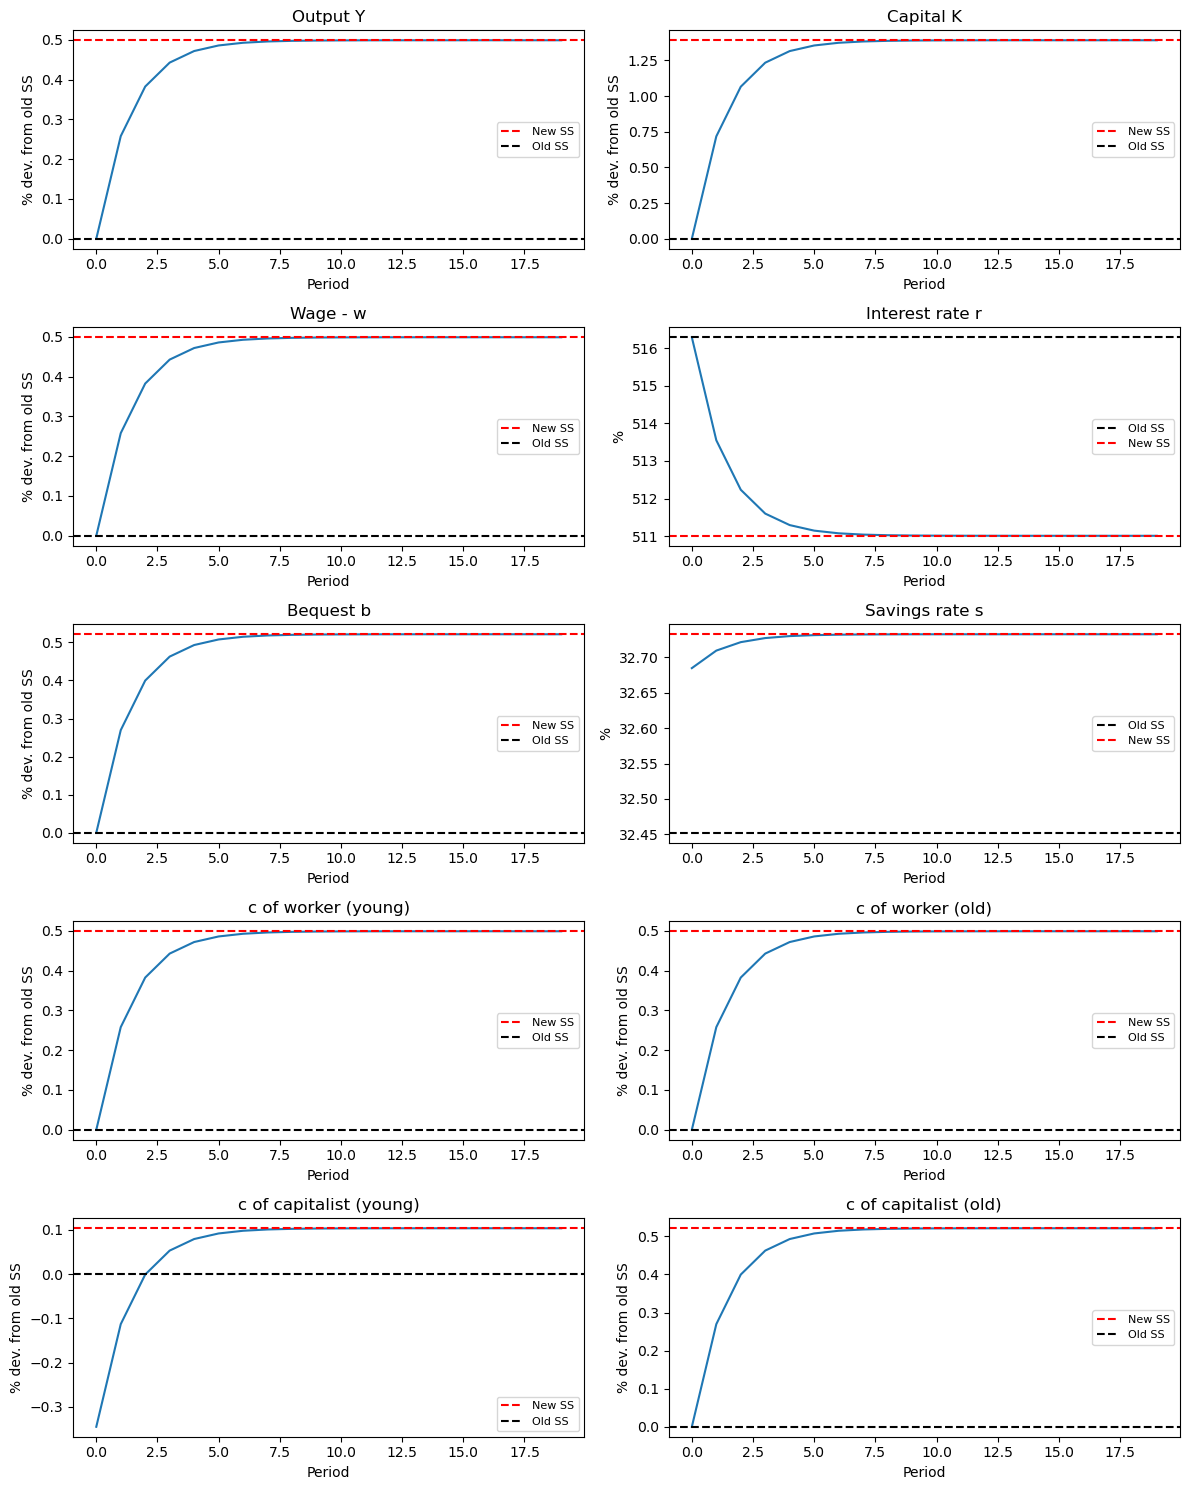

In [46]:
fig, axes = plt.subplots(5, 2, figsize=(12, 15))

pct_vars = [
    (sim3.Y, ss_no_tax.Y, ss_uncertain.Y, 'Output Y'),
    (sim3.K[:-1], ss_no_tax.K, ss_uncertain.K, 'Capital K'),
    (sim3.w, ss_no_tax.w, ss_uncertain.w, 'Wage - w'),
    (sim3.r, ss_no_tax.r, ss_uncertain.r, 'Interest rate r'),
    (sim3.b, ss_no_tax.b, ss_uncertain.b, 'Bequest b'),
    (sim3.s, ss_no_tax.s, ss_uncertain.s, 'Savings rate s'),
    (sim3.cW_y, ss_no_tax.cW_y, ss_uncertain.cW_y, 'c of worker (young)'),
    (sim3.cW_o, ss_no_tax.cW_o, ss_uncertain.cW_o, 'c of worker (old)'),
    (sim3.cK_y, ss_no_tax.cK_y, ss_uncertain.cK_y, 'c of capitalist (young)'),
    (sim3.cK_o, ss_no_tax.cK_o, ss_uncertain.cK_o, 'c of capitalist (old)'),
]

for i, (series, old, new, label) in enumerate(pct_vars):
    ax = axes[i // 2, i % 2]
    if label in ['Interest rate r', 'Savings rate s']:
        ax.plot(100 * series)
        ax.axhline(100 * old, color='black', linestyle='--', label='Old SS')
        ax.axhline(100 * new, color='red', linestyle='--', label='New SS')
        ax.legend(fontsize=8)
        ax.set_ylabel('%')
    else:
        ax.plot(100 * (series - old) / old)
        ax.axhline(100 * (new - old) / old, color='red', linestyle='--', label='New SS')
        ax.axhline(0, color='black', linestyle='--', label='Old SS')
        ax.legend(fontsize=8)
        ax.set_ylabel('% dev. from old SS')
    ax.set_title(label)
    ax.set_xlabel('Period')

plt.tight_layout()
plt.show()

The uncertainty steady state has higher capital than both part 2 and part 5. Compared to part 2, capital is higher because of precautionary savings. Capitalists save more to protect against the possible tax. Compared to Part 5, capital is also higher because the tax is never actually applied. So there is no direct reduction in after tax returns. The two mechanisms work in opposite directions. Actual taxes discourage saving, while uncertainty about taxes encourages saving. Workers benefit slightly from the higher capital stock through higher wages. The main takeaway is that the threat of a policy can have different effects than the policy itself. 

**AI has mainly been used to understand the mathematical aspects of this problem and with debugging of the code.**

<h3 style="color: steelblue; font-size: 2em; font-weight: bold;">Peer review comments - Part 6</h3>

- The Euler equation under uncertainty appears to be implemented correctly.
- The steady state with policy uncertainty is computed using the modified Euler equation, which is correct.
- The additional parameters introduced here (`tau_a_iid` and `pi_a`) are not initialized to zero from the beginning as in the suggested solution. But it does not chnage the rsult, so should not be any problem.
- The economic interpretation could be expanded. For example, the authors could explain that uncertainty about future taxes affects savings behavior because households adjust savings when future returns are uncertain.
- The paper could also discuss why the steady state changes under uncertainty, for example due to precautionary savings or changes in expected after-tax returns.
Adding more discussion of the economic mechanisms behind the results would strengthen this section.


